<a href="https://colab.research.google.com/github/TZN209/Grid/blob/master/NavieBayesClassifierImplementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
import random
import csv

In [ ]:
#load file and store its in mydata list
filename = '/content/Iris.csv'

mydata = csv.reader(open(filename, "rt"))
mydata = list(mydata)
del mydata[0]


In [ ]:
#ecode class names, change to numberic data
def encode_class(mydata):
  classes = []
  for i in range(len(mydata)):
    if mydata[i][-1] not in classes:
      classes.append(mydata[i][-1])
  for i in range(len(classes)):
    for j in range(len(mydata)):
      if mydata[j][-1] == classes[i]:
        mydata[j][-1] = i
  return mydata

mydata = encode_class(mydata)

[['1', '5.1', '3.5', '1.4', '0.2', 0],
 ['2', '4.9', '3.0', '1.4', '0.2', 0],
 ['3', '4.7', '3.2', '1.3', '0.2', 0],
 ['4', '4.6', '3.1', '1.5', '0.2', 0],
 ['5', '5.0', '3.6', '1.4', '0.2', 0],
 ['6', '5.4', '3.9', '1.7', '0.4', 0],
 ['7', '4.6', '3.4', '1.4', '0.3', 0],
 ['8', '5.0', '3.4', '1.5', '0.2', 0],
 ['9', '4.4', '2.9', '1.4', '0.2', 0],
 ['10', '4.9', '3.1', '1.5', '0.1', 0],
 ['11', '5.4', '3.7', '1.5', '0.2', 0],
 ['12', '4.8', '3.4', '1.6', '0.2', 0],
 ['13', '4.8', '3.0', '1.4', '0.1', 0],
 ['14', '4.3', '3.0', '1.1', '0.1', 0],
 ['15', '5.8', '4.0', '1.2', '0.2', 0],
 ['16', '5.7', '4.4', '1.5', '0.4', 0],
 ['17', '5.4', '3.9', '1.3', '0.4', 0],
 ['18', '5.1', '3.5', '1.4', '0.3', 0],
 ['19', '5.7', '3.8', '1.7', '0.3', 0],
 ['20', '5.1', '3.8', '1.5', '0.3', 0],
 ['21', '5.4', '3.4', '1.7', '0.2', 0],
 ['22', '5.1', '3.7', '1.5', '0.4', 0],
 ['23', '4.6', '3.6', '1.0', '0.2', 0],
 ['24', '5.1', '3.3', '1.7', '0.5', 0],
 ['25', '4.8', '3.4', '1.9', '0.2', 0],
 ['26', '

In [ ]:
for i in range(len(mydata)):
  mydata[i] = [ float(x) for x in mydata[i][1:] ]


In [ ]:
#Split the data

def splitting(mydata, ratio):
  train_num = int(len(mydata) * ratio)
  train = []

  test = list(mydata)
  while len(train) < train_num:
    #generate index randomly from 0 to length of the test data
    index = random.randrange(len(test))
    #from testset, pop data row and put it in train
    train.append(test.pop(index))
  return train, test

#split ratio = 0.7
ratio = 0.7

train_data, test_data = splitting(mydata, ratio)

print("Total number of examples are: ", len(mydata))
print("Total number of training set are: ", len(train_data))
print("Total number of test set are: ", len(test_data))


Total number of examples are:  150
Total number of training set are:  105
Total number of test set are:  45


In [ ]:
def groupUnderClass(data):
  group_dict = {}
  for i in range(len(data)):
    if data[i][-1] not in group_dict:
      group_dict[data[i][-1]] = []
    group_dict[data[i][-1]].append(data[i])
  return group_dict



In [ ]:
#calculating Mean
def mean(numbers):
  return sum(numbers) / float(len(numbers))

#Calculating Standard Deviation
def std_dev(numbers):
  avg = mean(numbers)
  varience = sum([ pow(x - avg, 2) for x in numbers ]) / float(len(numbers) - 1)
  return math.sqrt(varience)
#[[5.1, 3.7, 1.5, 0.4, 0.0],
#  [5.7, 4.4, 1.5, 0.4, 0.0],
#  [4.8, 3.0, 1.4, 0.3, 0.0],
#  [5.1, 3.5, 1.4, 0.2, 0.0],
#  [4.6, 3.6, 1.0, 0.2, 0.0],
#  [5.4, 3.9, 1.7, 0.4, 0.0]]
#zip => [[5.1 5.7 4.8 5.1 4.6 5.4], [3.7, 4.4, 3.0, 3.5, ...]...]

def MeanAndStdDev(data):
  info = [(mean(feature_vector), std_dev(feature_vector)) for feature_vector in zip(*data)]
  del info[-1]
  return info



In [ ]:
group_dict = groupUnderClass(train_data)

def MeanAndStdDevForClass(group_dict):
  info = {}
  for classValue, instances in group_dict.items():
    info[classValue] = MeanAndStdDev(instances)
  return info



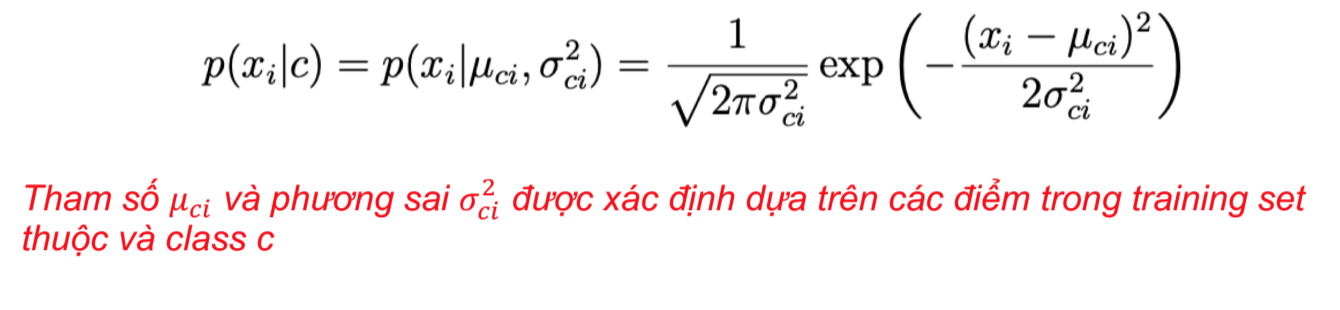

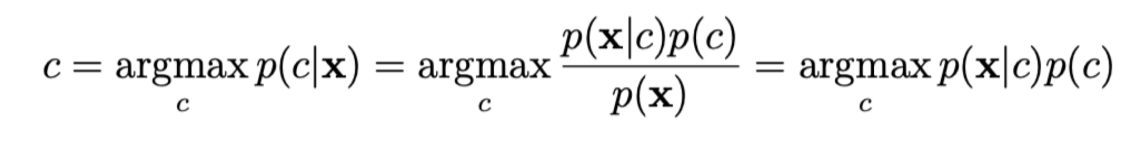

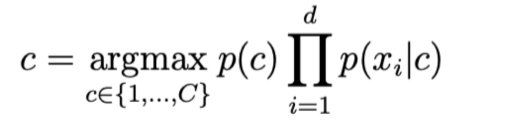

In [ ]:
#Calculate Gaussian Probility Desity Function
#P(x_i | c)
def calculateGaussianProbility(x_i, mean, std_dev):
  expo = math.exp( - ( pow(x_i - mean, 2)/(2* math.pow(std_dev, 2))))
  return (1/(math.sqrt(2*math.pi) * std_dev)) * expo


#Calculate Class Probabilities
#P(c|x)
def calculateClassProbilities(info, x):
  probilities = {}
  #Get std_dev, mean of each class
  for classValue, classSummaries in info.items():
    probilities[classValue] = len(group_dict[classValue]) / float(len(train_data))
    for i in range(len(classSummaries)):
      mean, std_dev = classSummaries[i]
      x_i = x[i]
      probilities[classValue] *= calculateGaussianProbility(x_i, mean, std_dev)
  return probilities


In [ ]:
#Make prediction - highest probility is the prediction
def predict(info, x):
  probilities = calculateClassProbilities(info, x)
  bestLabel, bestProb = None, -1
  for classValue, probility in probilities.items():
    if bestLabel is None or probility > bestProb:
      bestProb = probility
      bestLabel = classValue
  return bestLabel


In [ ]:
def getPredictions(info, test):
  predictions = []
  for i in range(len(test)):
    result = predict(info, test[i])
    predictions.append(result)
  return predictions

In [ ]:
def accuracy_rate(test, predictions):
  correct = 0
  for i in range(len(test)):
    if predictions[i] == test[i][-1]:
      correct += 1
  return (correct / float(len(test))) * 100

In [ ]:
#Prepare model
info = MeanAndStdDevForClass(group_dict)
#Test model
predictions = getPredictions(info, test_data)
accuracy = accuracy_rate(test_data, predictions)

print("Accuracy of your model is: ", accuracy)

Accuracy of your model is:  95.55555555555556
